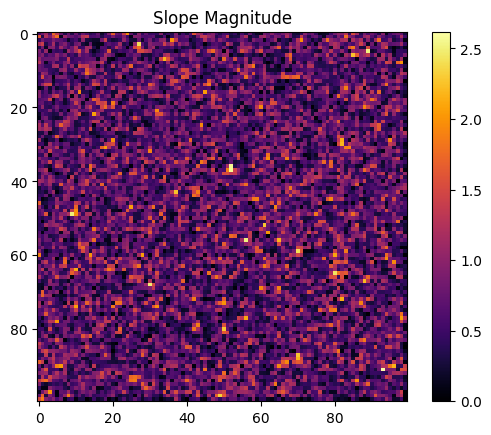

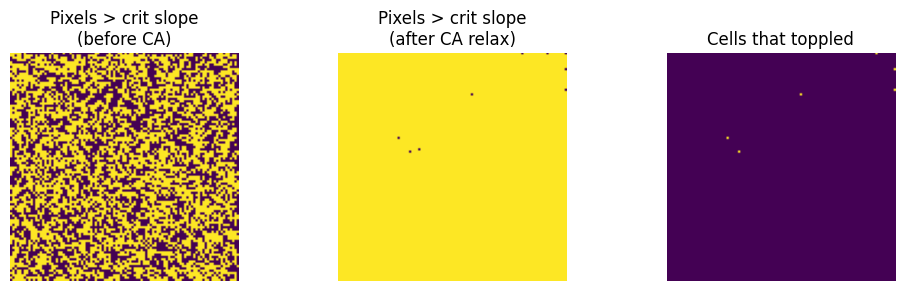

In [6]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
H = np.linspace(50, 0, ny).reshape(-1, 1) + gaussian_filter(np.random.randn(ny, nx), sigma=2)
slope_mag = np.sqrt((dx / 5)**2 + (dy / 5)**2)
plt.imshow(slope_mag, cmap='inferno'); plt.colorbar(); plt.title('Slope Magnitude'); plt.show()


# create a simple synthetic 2‑D slope (100 x 100 cells, 5 m grid)
np.random.seed(0)
ny, nx = 100, 100
H = np.linspace(50, 0, ny).reshape(-1, 1) + 2 * np.random.randn(ny, nx)

# compute 4‑neighbour slope magnitude (rise/run ~ tanθ)
dx = np.diff(H, axis=1, append=H[:, -1:])
dy = np.diff(H, axis=0, append=H[-1:, :])
slope_mag = np.sqrt((dx / 5)**2 + (dy / 5)**2)  # fixed from *2 to **2
crit = 0.577  # tan(30°)
unstable_mask_init = slope_mag > crit

# --- sand‑pile cellular automaton (optimized) ---
H_ca = H.copy()
changed = True
max_iter = 500
iter_count = 0

while changed and iter_count < max_iter:
    changed = False
    iter_count += 1
    for shift, axis in [(-1, 1), (1, 1), (-1, 0), (1, 0)]:  # left, right, up, down
        nbr = np.roll(H_ca, shift, axis=axis)
        slope = np.abs((H_ca - nbr) / 5)
        mask = slope > crit
        if mask.any():
            changed = True
            delta = 0.2 * (H_ca - nbr)
            H_ca[mask] -= delta[mask]
            nbr_mask = np.roll(mask, shift, axis=axis)
            nbr[nbr_mask] += delta[mask]
            H_ca = np.roll(nbr, -shift, axis=axis)  # <-- always update

# compute final slope & unstable map
dx_final = np.diff(H_ca, axis=1, append=H_ca[:, -1:])
dy_final = np.diff(H_ca, axis=0, append=H_ca[-1:, :])
slope_final = np.sqrt((dx_final / 5)**2 + (dy_final / 5)**2)
unstable_mask_final = slope_final > crit

# quick visual proof
fig, axs = plt.subplots(1, 3, figsize=(10, 3))
axs[0].imshow(unstable_mask_init, origin='lower')
axs[0].set_title('Pixels > crit slope\n(before CA)')
axs[1].imshow(unstable_mask_final, origin='lower')
axs[1].set_title('Pixels > crit slope\n(after CA relax)')
axs[2].imshow((unstable_mask_init & ~unstable_mask_final), origin='lower')
axs[2].set_title('Cells that toppled')
for ax in axs: ax.axis('off')
plt.tight_layout()

